<a href="https://colab.research.google.com/github/singhayushi14470-collab/Machine_Learning_1/blob/main/decision_tree_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Decision Tree

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
iris=sns.load_dataset("iris")
iris.head()



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [10]:
iris.shape

(150, 5)

In [12]:
x = iris[['sepal_length', 'sepal_width']]
y = iris['species']

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
x_train

,sepal_length,sepal_width
22,4.6,3.6
15,5.7,4.4
65,6.7,3.1
11,4.8,3.4
42,4.4,3.2
...,...,...
71,6.1,2.8
106,4.9,2.5
14,5.8,4.0
92,5.8,2.6


In [29]:
clf=DecisionTreeClassifier(max_depth=2)
clf.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=2)

In [30]:
y_pred=clf.predict(x_test)


In [31]:
score=accuracy_score(y_test,y_pred)
print(score)

0.8


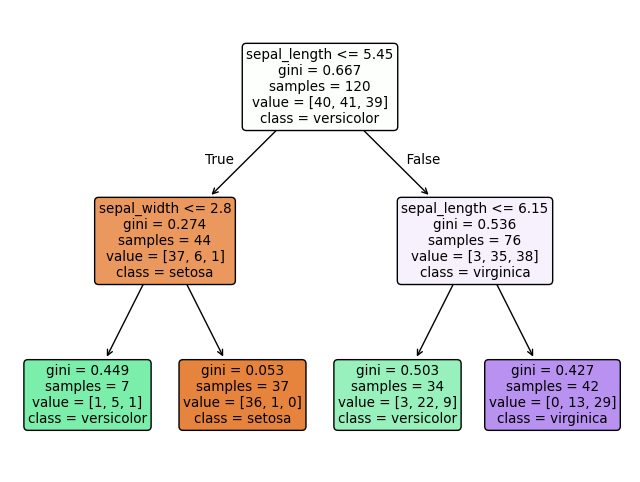

In [32]:
# plot decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(8,6))
plot_tree(clf,filled=True,feature_names=['sepal_length', 'sepal_width'],class_names=iris['species'].unique(),rounded=True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


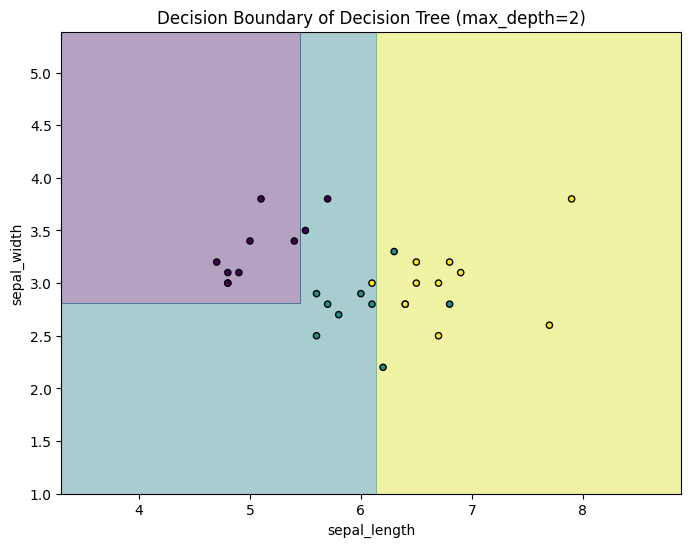

In [34]:
# create decision boundary
plt.figure(figsize=(8,6))

x_min_val, x_max_val = x['sepal_length'].min() - 1, x['sepal_length'].max() + 1
y_min_val, y_max_val = x['sepal_width'].min() - 1, x['sepal_width'].max() + 1

# Generate a grid of points for the decision boundary plot
xx_grid, yy_grid = np.meshgrid(np.arange(x_min_val, x_max_val, 0.01),
                               np.arange(y_min_val, y_max_val, 0.01))

# Predict class for each point on the grid
Z = clf.predict(np.c_[xx_grid.ravel(), yy_grid.ravel()])

# Convert string predictions to numerical labels for contourf
# Use clf.classes_ to ensure correct mapping order
label_to_int = {label: i for i, label in enumerate(clf.classes_)}
Z_numeric = np.array([label_to_int[label] for label in Z])

# Reshape the numerical predictions to match the grid shape
Z_numeric = Z_numeric.reshape(xx_grid.shape)

# Plot the decision boundary
plt.contourf(xx_grid, yy_grid, Z_numeric, alpha=0.4)

# Plot the test data points
# Map y_test labels to numerical values for consistent coloring
y_test_numeric = y_test.map(label_to_int)
plt.scatter(x_test['sepal_length'], x_test['sepal_width'], c=y_test_numeric, s=20, edgecolor='k')

plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.title('Decision Boundary of Decision Tree (max_depth=2)')
plt.show()